<a href="https://colab.research.google.com/github/karvaroz/ML_CRASH_COURSE/blob/main/loan_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loan Data — Exploratory Data Analysis & Predictive Modeling

**Dataset:** LendingClub Loan Data (~9,578 loans)  
**Goal:** Understand what factors drive loan default and build a predictive model  
**Target variable:** `not.fully.paid` — 1 if the borrower defaulted, 0 if fully paid

---

## Table of Contents
1. [Setup & Data Loading](#1-setup)
2. [Business Understanding](#2-business)
3. [EDA — Individual Variables](#3-eda-individual)
4. [EDA — Relationships with Target](#4-eda-target)
5. [Preprocessing](#5-preprocessing)
6. [Predictive Model](#6-model)
7. [Conclusions & Key Insights](#7-conclusions)

## 1. Setup & Data Loading

In [1]:
# Install if running on Colab
# !pip install pandas matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded successfully')

Libraries loaded successfully


In [3]:
# Mount Google Drive and load dataset
from google.colab import drive
drive.mount('/content/drive')

# Path: My Drive > Colabs Notebooks > data > loan_data.csv
FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/data/loan_data.csv'
# https://www.datacamp.com/datalab/datasets/dataset-python-loans

df = pd.read_csv(FILE_PATH)

print(f'Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (9578, 14)
Rows: 9,578 | Columns: 14


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.1000,11.3504,19.4800,737,5639.9583,28854,52.1000,0,0,0,0
1,1,credit_card,0.1071,228.2200,11.0821,14.2900,707,2760.0000,33623,76.7000,0,0,0,0
2,1,debt_consolidation,0.1357,366.8600,10.3735,11.6300,682,4710.0000,3511,25.6000,1,0,0,0
3,1,debt_consolidation,0.1008,162.3400,11.3504,8.1000,712,2699.9583,33667,73.2000,1,0,0,0
4,1,credit_card,0.1426,102.9200,11.2997,14.9700,667,4066.0000,4740,39.5000,0,1,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [5]:
df.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.0000,9578.0000,9578.0000,9578.0000,9578.0000,9578.0000,9578.0000,9578.0000,9578.0000,9578.0000,9578.0000,9578.0000,9578.0000
mean,0.8050,0.1226,319.0894,10.9321,12.6067,710.8463,4560.7672,16913.9639,46.7992,1.5775,0.1637,0.0621,0.1601
std,0.3962,0.0268,207.0713,0.6148,6.8840,37.9705,2496.9304,33756.1896,29.0144,2.2002,0.5462,0.2621,0.3667
min,0.0000,0.0600,15.6700,7.5475,0.0000,612.0000,178.9583,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,1.0000,0.1039,163.7700,10.5584,7.2125,682.0000,2820.0000,3187.0000,22.6000,0.0000,0.0000,0.0000,0.0000
50%,1.0000,0.1221,268.9500,10.9289,12.6650,707.0000,4139.9583,8596.0000,46.3000,1.0000,0.0000,0.0000,0.0000
75%,1.0000,0.1407,432.7625,11.2913,17.9500,737.0000,5730.0000,18249.5000,70.9000,2.0000,0.0000,0.0000,0.0000
max,1.0000,0.2164,940.1400,14.5284,29.9600,827.0000,17639.9583,1207359.0000,119.0000,33.0000,13.0000,5.0000,1.0000


In [6]:
# Check missing values
nulls = df.isnull().sum()
print('Missing values per column:')
print(nulls[nulls > 0] if nulls.sum() > 0 else 'No missing values found')

Missing values per column:
No missing values found


## 2. Business Understanding

### What problem are we solving?

LendingClub is a peer-to-peer lending platform. Investors lend money to individuals, and the key risk is **credit default** — a borrower failing to repay the loan.

### Business question
> **Can we predict, at the time of loan issuance, whether a borrower will default?**

### Column dictionary

| Column | Type | Description |
|---|---|---|
| `credit.policy` | binary | 1 if borrower meets LendingClub credit criteria |
| `purpose` | categorical | Reason for the loan |
| `int.rate` | float | Interest rate assigned to the loan |
| `installment` | float | Monthly payment amount |
| `log.annual.inc` | float | Natural log of borrower's annual income |
| `dti` | float | Debt-to-income ratio |
| `fico` | int | FICO credit score (300–850) |
| `days.with.cr.line` | float | Days borrower has had a credit line |
| `revol.bal` | int | Revolving balance (unpaid credit card debt) |
| `revol.util` | float | Revolving line utilization rate (%) |
| `inq.last.6mths` | int | Credit inquiries in last 6 months |
| `delinq.2yrs` | int | Late payments in past 2 years |
| `pub.rec` | int | Derogatory public records (bankruptcies) |
| **`not.fully.paid`** | **binary** | **TARGET: 1 = defaulted, 0 = fully paid** |

### Why `int.rate` matters
Interest rate is not random — LendingClub assigns it based on perceived risk. Higher rate = riskier borrower. This creates a direct relationship: high `int.rate` loans should have higher default rates.

## 3. EDA — Individual Variables

We explore each variable independently before looking at relationships.

Target distribution:
  Fully Paid   (0): 8,045 (84.0%)
  Defaulted    (1): 1,533 (16.0%)

Dataset is IMBALANCED — 84% paid, 16% defaulted


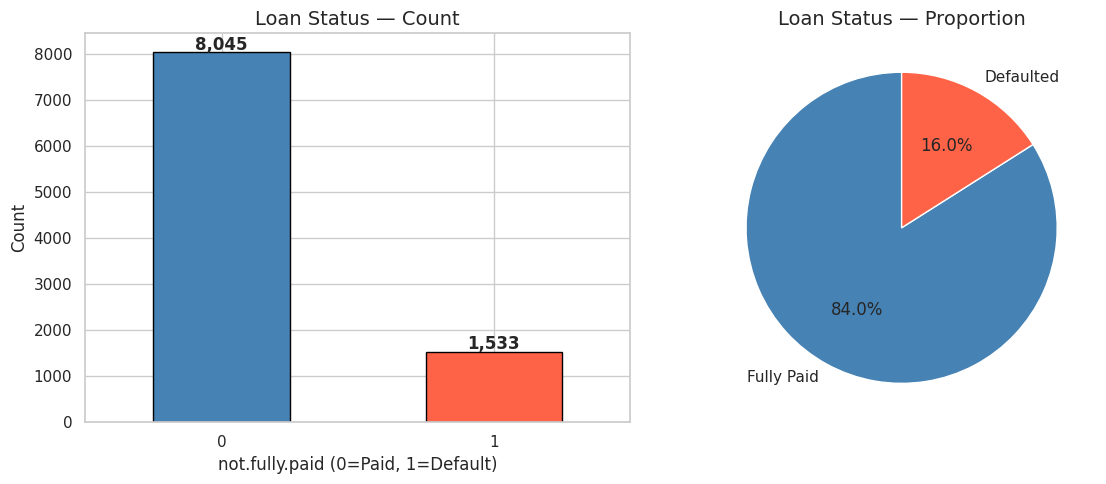

In [7]:
# --- Target variable distribution ---
target_counts = df['not.fully.paid'].value_counts()
target_pct = df['not.fully.paid'].value_counts(normalize=True) * 100

print('Target distribution:')
print(f'  Fully Paid   (0): {target_counts[0]:,} ({target_pct[0]:.1f}%)')
print(f'  Defaulted    (1): {target_counts[1]:,} ({target_pct[1]:.1f}%)')
print()
print('Dataset is IMBALANCED — 84% paid, 16% defaulted')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
target_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Loan Status — Count', fontsize=14)
axes[0].set_xlabel('not.fully.paid (0=Paid, 1=Default)')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)
for i, v in enumerate(target_counts):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts, labels=['Fully Paid', 'Defaulted'], autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Loan Status — Proportion', fontsize=14)

plt.tight_layout()
plt.show()

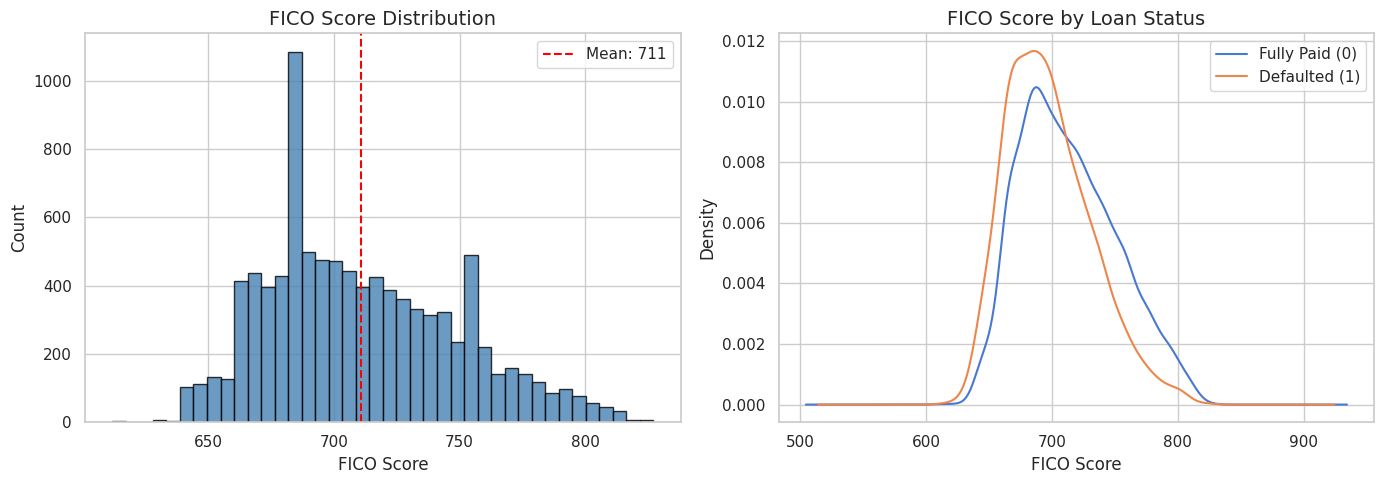

Mean FICO — Paid: 713.3
Mean FICO — Default: 697.8


In [8]:
# --- FICO Score distribution ---
# FICO is the most important credit metric — ranges from 300 to 850
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['fico'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('FICO Score Distribution', fontsize=14)
axes[0].set_xlabel('FICO Score')
axes[0].set_ylabel('Count')
axes[0].axvline(df['fico'].mean(), color='red', linestyle='--', label=f"Mean: {df['fico'].mean():.0f}")
axes[0].legend()

# FICO by default status
df.groupby('not.fully.paid')['fico'].plot(kind='kde', ax=axes[1])
axes[1].set_title('FICO Score by Loan Status', fontsize=14)
axes[1].set_xlabel('FICO Score')
axes[1].legend(['Fully Paid (0)', 'Defaulted (1)'])

plt.tight_layout()
plt.show()

print(f"Mean FICO — Paid: {df[df['not.fully.paid']==0]['fico'].mean():.1f}")
print(f"Mean FICO — Default: {df[df['not.fully.paid']==1]['fico'].mean():.1f}")

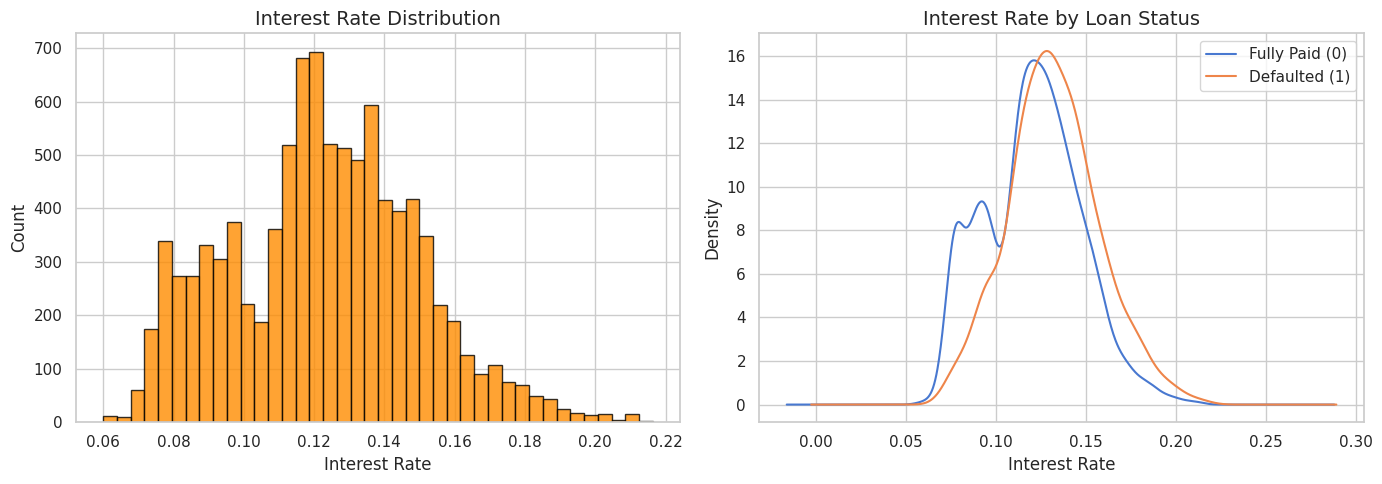

Mean Interest Rate — Paid: 0.1208
Mean Interest Rate — Default: 0.1325


In [9]:
# --- Interest Rate distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['int.rate'].hist(bins=40, ax=axes[0], color='darkorange', edgecolor='black', alpha=0.8)
axes[0].set_title('Interest Rate Distribution', fontsize=14)
axes[0].set_xlabel('Interest Rate')
axes[0].set_ylabel('Count')

df.groupby('not.fully.paid')['int.rate'].plot(kind='kde', ax=axes[1])
axes[1].set_title('Interest Rate by Loan Status', fontsize=14)
axes[1].set_xlabel('Interest Rate')
axes[1].legend(['Fully Paid (0)', 'Defaulted (1)'])

plt.tight_layout()
plt.show()

print(f"Mean Interest Rate — Paid: {df[df['not.fully.paid']==0]['int.rate'].mean():.4f}")
print(f"Mean Interest Rate — Default: {df[df['not.fully.paid']==1]['int.rate'].mean():.4f}")

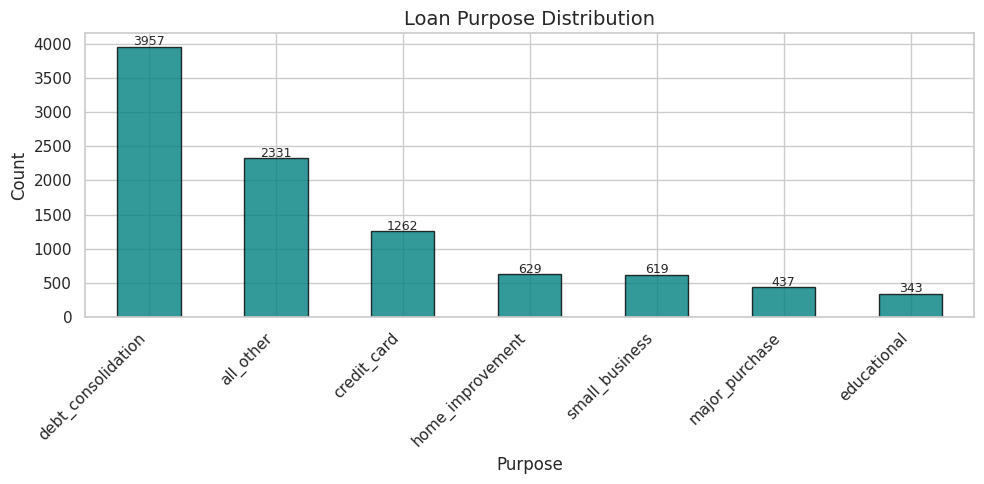

Most common loan purpose: debt consolidation
Observation: people often take loans to pay off other debts — signals financial stress


In [10]:
# --- Purpose distribution ---
purpose_counts = df['purpose'].value_counts()

plt.figure(figsize=(10, 5))
purpose_counts.plot(kind='bar', color='teal', edgecolor='black', alpha=0.8)
plt.title('Loan Purpose Distribution', fontsize=14)
plt.xlabel('Purpose')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(purpose_counts):
    plt.text(i, v + 20, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print('Most common loan purpose: debt consolidation')
print('Observation: people often take loans to pay off other debts — signals financial stress')

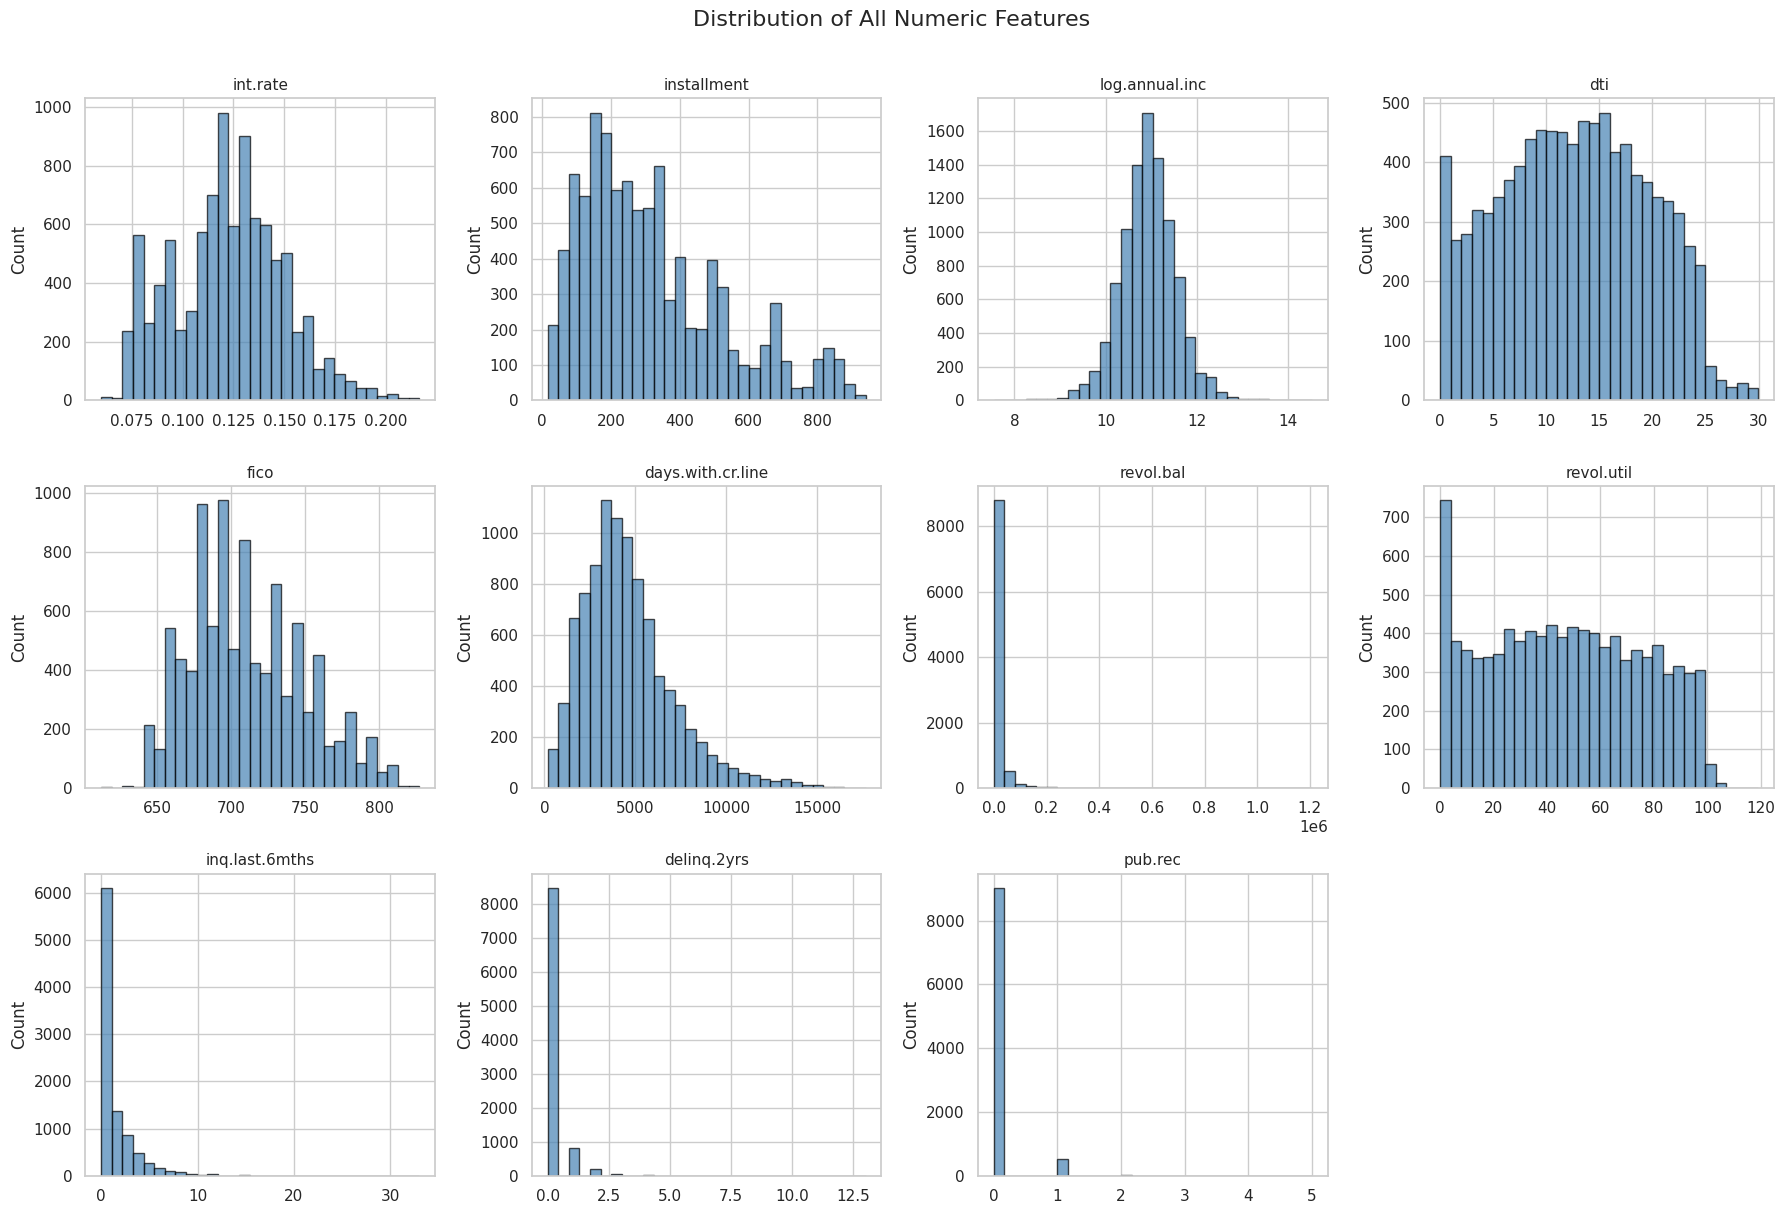

In [11]:
# --- Overview of all numeric distributions ---
numeric_cols = ['int.rate', 'installment', 'log.annual.inc', 'dti',
                'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
                'inq.last.6mths', 'delinq.2yrs', 'pub.rec']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=30, ax=axes[i], color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Count')

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle('Distribution of All Numeric Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 4. EDA — Relationships with Target

Now we examine how each feature relates to `not.fully.paid`.

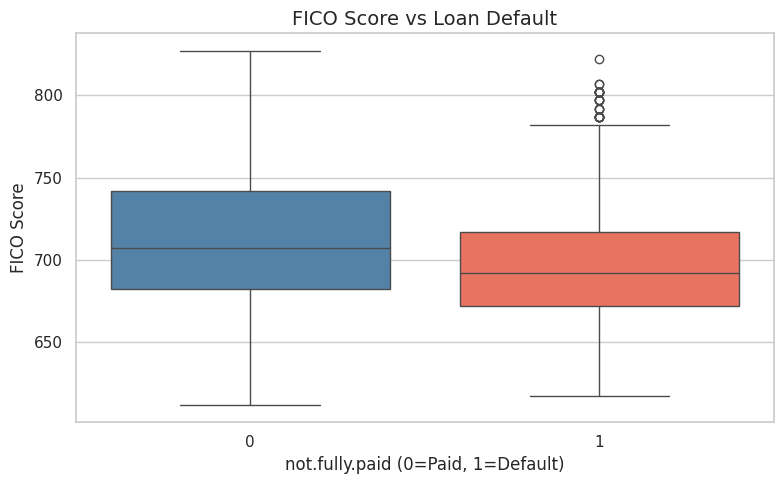

FICO statistics by loan status:
                   count     mean     std      min      25%      50%      75%  \
not.fully.paid                                                                  
0              8045.0000 713.3269 38.2237 612.0000 682.0000 707.0000 742.0000   
1              1533.0000 697.8284 33.7568 617.0000 672.0000 692.0000 717.0000   

                    max  
not.fully.paid           
0              827.0000  
1              822.0000  


In [13]:
# --- FICO vs Default (boxplot) ---
# Key question: do defaulters have lower FICO scores?
plt.figure(figsize=(8, 5))
sns.boxplot(x='not.fully.paid', y='fico', data=df,
            hue='not.fully.paid', palette=['steelblue', 'tomato'], legend=False)
plt.title('FICO Score vs Loan Default', fontsize=14)
plt.xlabel('not.fully.paid (0=Paid, 1=Default)')
plt.ylabel('FICO Score')
plt.tight_layout()
plt.show()

# Statistical summary
print('FICO statistics by loan status:')
print(df.groupby('not.fully.paid')['fico'].describe())

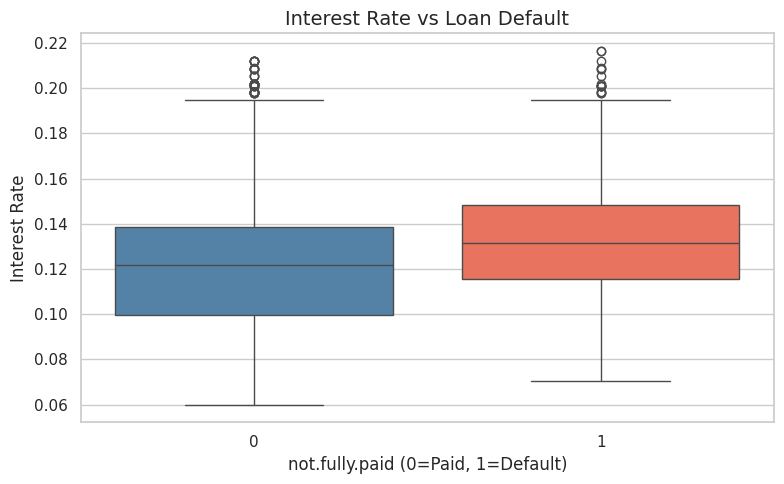

Interest rate statistics by loan status:
                   count   mean    std    min    25%    50%    75%    max
not.fully.paid                                                           
0              8045.0000 0.1208 0.0267 0.0600 0.0996 0.1218 0.1387 0.2121
1              1533.0000 0.1325 0.0255 0.0705 0.1154 0.1316 0.1482 0.2164


In [15]:
# --- Interest Rate vs Default ---
# Key insight: higher rate = higher risk (lender already priced it in)
plt.figure(figsize=(8, 5))
sns.boxplot(x='not.fully.paid', y='int.rate', data=df,
            hue='not.fully.paid', palette=['steelblue', 'tomato'], legend=False)
plt.title('Interest Rate vs Loan Default', fontsize=14)
plt.xlabel('not.fully.paid (0=Paid, 1=Default)')
plt.ylabel('Interest Rate')
plt.tight_layout()
plt.show()

print('Interest rate statistics by loan status:')
print(df.groupby('not.fully.paid')['int.rate'].describe())

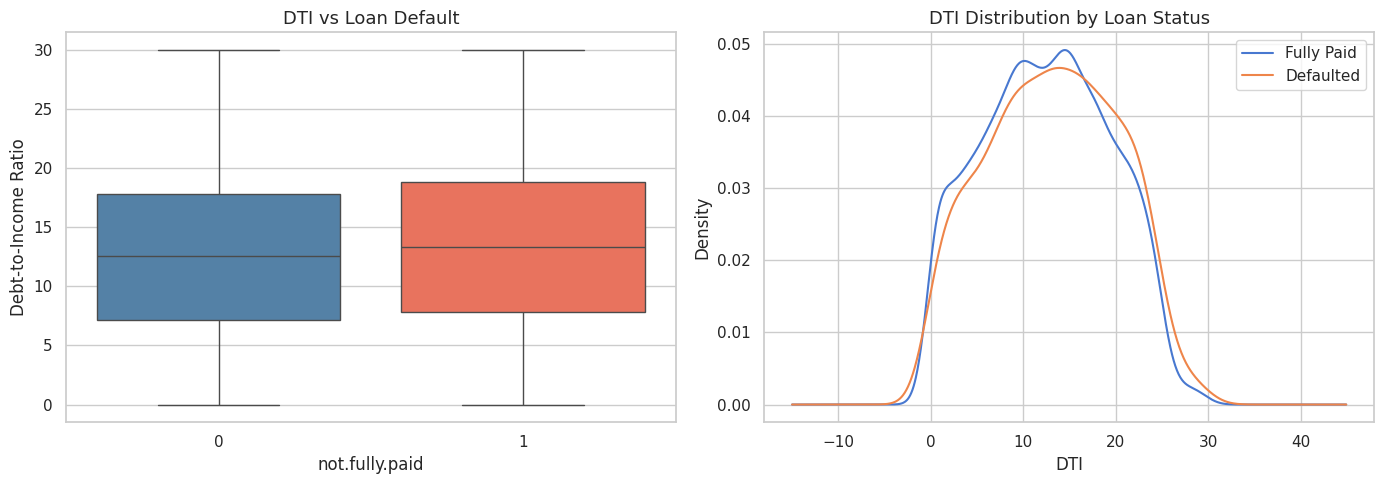

DTI mean by status:
not.fully.paid
0   12.4944
1   13.1958
Name: dti, dtype: float64


In [17]:
# --- DTI (Debt-to-Income) vs Default ---
# DTI = total monthly debt / gross monthly income
# Higher DTI = borrower already stretched thin
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='not.fully.paid', y='dti', data=df,
            hue='not.fully.paid', palette=['steelblue', 'tomato'], legend=False, ax=axes[0])
axes[0].set_title('DTI vs Loan Default', fontsize=13)
axes[0].set_xlabel('not.fully.paid')
axes[0].set_ylabel('Debt-to-Income Ratio')

df.groupby('not.fully.paid')['dti'].plot(kind='kde', ax=axes[1])
axes[1].set_title('DTI Distribution by Loan Status', fontsize=13)
axes[1].set_xlabel('DTI')
axes[1].legend(['Fully Paid', 'Defaulted'])

plt.tight_layout()
plt.show()

print('DTI mean by status:')
print(df.groupby('not.fully.paid')['dti'].mean())

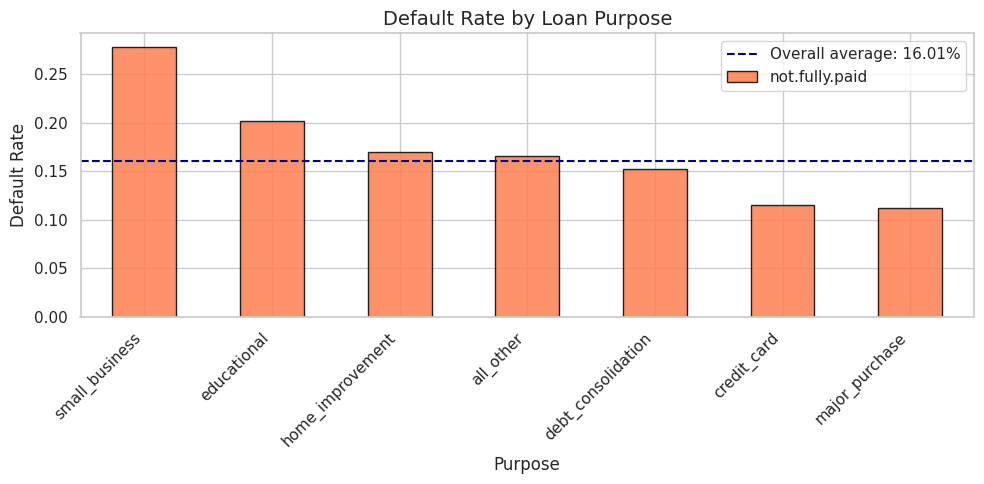

Default rate by purpose:
purpose
small_business        27.79%
educational           20.12%
home_improvement      17.01%
all_other              16.6%
debt_consolidation    15.24%
credit_card           11.57%
major_purchase        11.21%
Name: not.fully.paid, dtype: object


In [18]:
# --- Default Rate by Purpose ---
# Which loan purposes have the highest default rate?
purpose_default = df.groupby('purpose')['not.fully.paid'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
purpose_default.plot(kind='bar', color='coral', edgecolor='black', alpha=0.85)
plt.title('Default Rate by Loan Purpose', fontsize=14)
plt.xlabel('Purpose')
plt.ylabel('Default Rate')
plt.xticks(rotation=45, ha='right')
plt.axhline(df['not.fully.paid'].mean(), color='navy', linestyle='--',
            label=f"Overall average: {df['not.fully.paid'].mean():.2%}")
plt.legend()
plt.tight_layout()
plt.show()

print('Default rate by purpose:')
print((purpose_default * 100).round(2).astype(str) + '%')

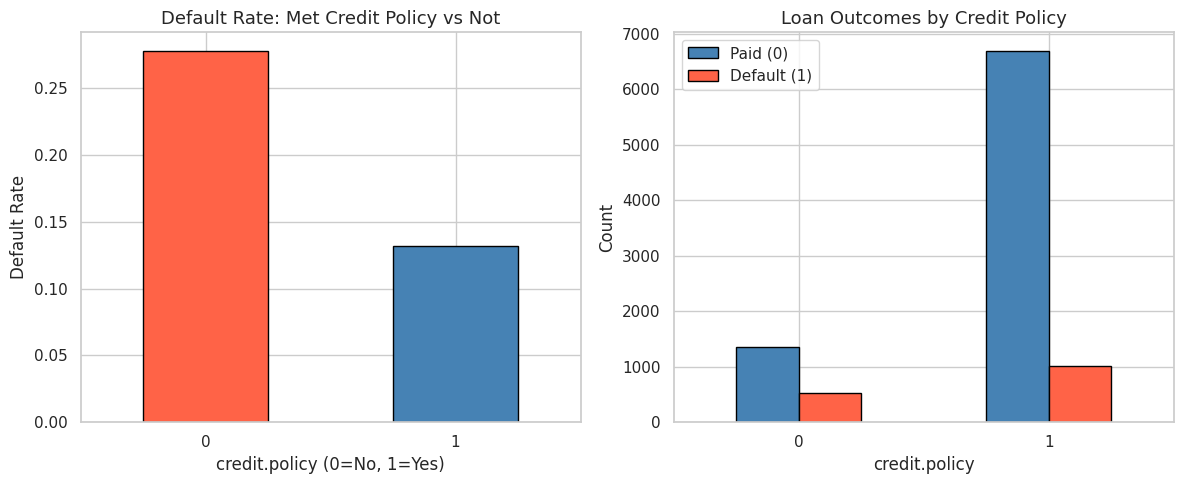

Insight: borrowers who did NOT meet credit policy defaulted at a higher rate
Credit policy 0 (no): 27.78% default rate
Credit policy 1 (yes): 13.15% default rate


In [19]:
# --- Credit Policy vs Default ---
# Did meeting credit criteria protect against default?
cp_default = df.groupby('credit.policy')['not.fully.paid'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cp_default.plot(kind='bar', ax=axes[0], color=['tomato', 'steelblue'], edgecolor='black')
axes[0].set_title('Default Rate: Met Credit Policy vs Not', fontsize=13)
axes[0].set_xlabel('credit.policy (0=No, 1=Yes)')
axes[0].set_ylabel('Default Rate')
axes[0].tick_params(rotation=0)

df.groupby('credit.policy')['not.fully.paid'].value_counts().unstack().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='black')
axes[1].set_title('Loan Outcomes by Credit Policy', fontsize=13)
axes[1].set_xlabel('credit.policy')
axes[1].set_ylabel('Count')
axes[1].tick_params(rotation=0)
axes[1].legend(['Paid (0)', 'Default (1)'])

plt.tight_layout()
plt.show()

print('Insight: borrowers who did NOT meet credit policy defaulted at a higher rate')
print(f"Credit policy 0 (no): {cp_default[0]:.2%} default rate")
print(f"Credit policy 1 (yes): {cp_default[1]:.2%} default rate")

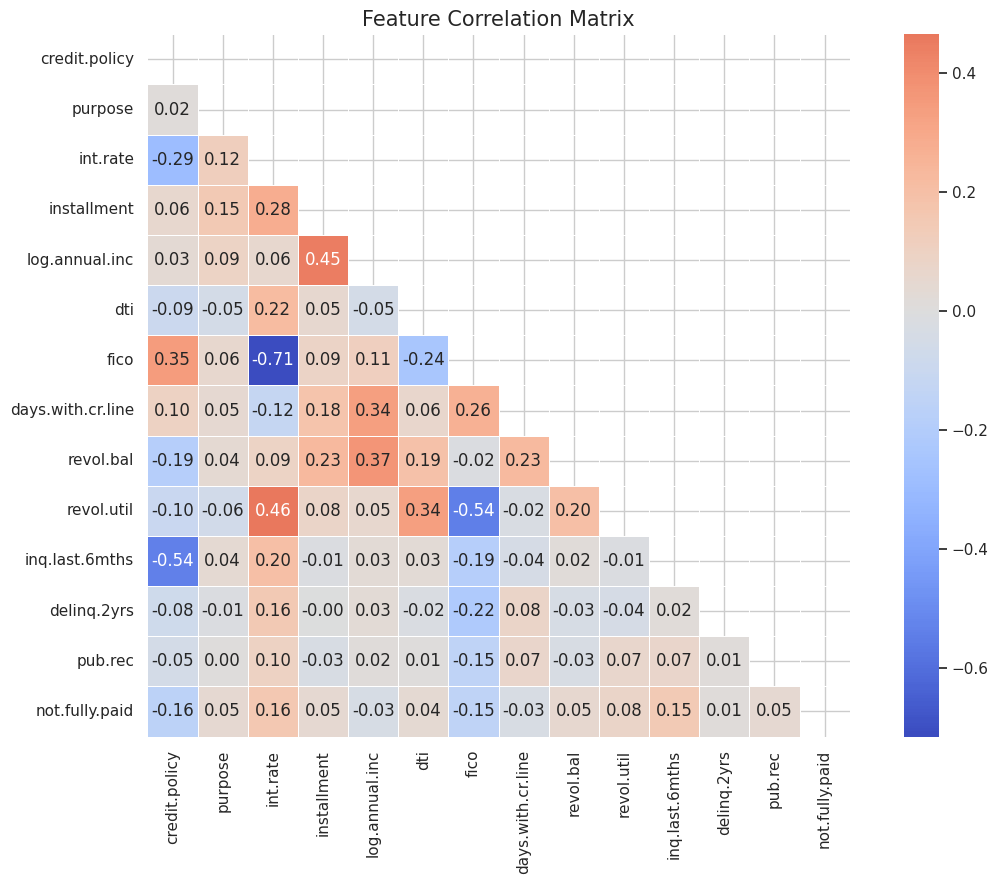

Top correlations with not.fully.paid:
int.rate            0.1596
credit.policy       0.1581
fico                0.1497
inq.last.6mths      0.1495
revol.util          0.0821
revol.bal           0.0537
installment         0.0500
pub.rec             0.0486
purpose             0.0479
dti                 0.0374
log.annual.inc      0.0334
days.with.cr.line   0.0292
delinq.2yrs         0.0089
Name: not.fully.paid, dtype: float64


In [20]:
# --- Correlation Heatmap ---
# Encode 'purpose' to check correlation
df_encoded = df.copy()
df_encoded['purpose'] = LabelEncoder().fit_transform(df['purpose'])

plt.figure(figsize=(12, 9))
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # Show only lower triangle
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=15)
plt.tight_layout()
plt.show()

# Top correlations with target
print('Top correlations with not.fully.paid:')
print(corr['not.fully.paid'].drop('not.fully.paid').abs().sort_values(ascending=False))

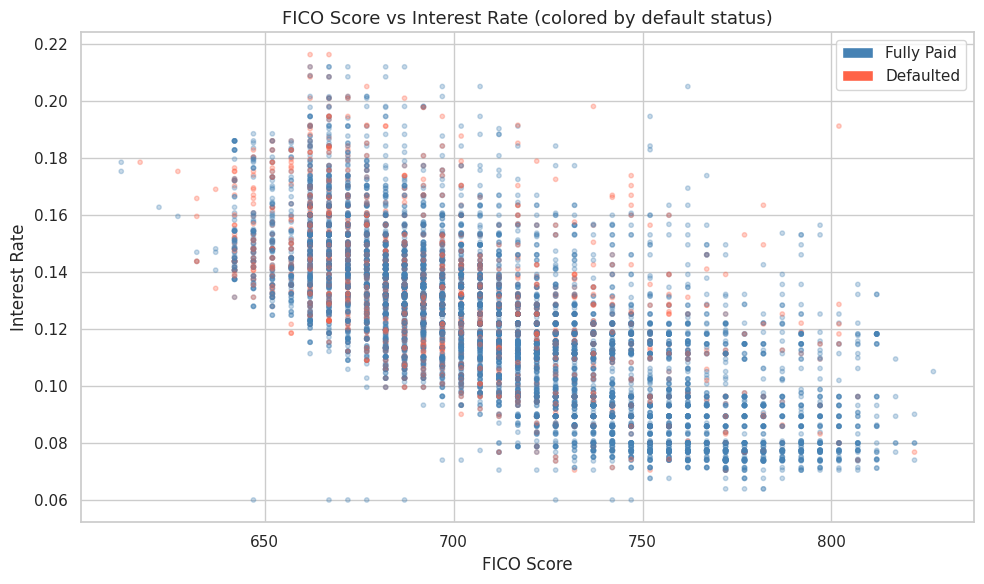

Key finding:
- Clear negative correlation between FICO and interest rate
- Defaults (red) cluster in the high interest rate / low FICO region
- The lender's risk pricing is directionally correct


In [21]:
# --- FICO vs Interest Rate (colored by default) ---
# This plot shows HOW the lender prices risk:
# Lower FICO → higher interest rate (lender charges more for riskier borrowers)
plt.figure(figsize=(10, 6))
colors = df['not.fully.paid'].map({0: 'steelblue', 1: 'tomato'})
plt.scatter(df['fico'], df['int.rate'], c=colors, alpha=0.3, s=10)
plt.title('FICO Score vs Interest Rate (colored by default status)', fontsize=13)
plt.xlabel('FICO Score')
plt.ylabel('Interest Rate')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Fully Paid'),
                   Patch(facecolor='tomato', label='Defaulted')]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

print('Key finding:')
print('- Clear negative correlation between FICO and interest rate')
print('- Defaults (red) cluster in the high interest rate / low FICO region')
print('- The lender\'s risk pricing is directionally correct')

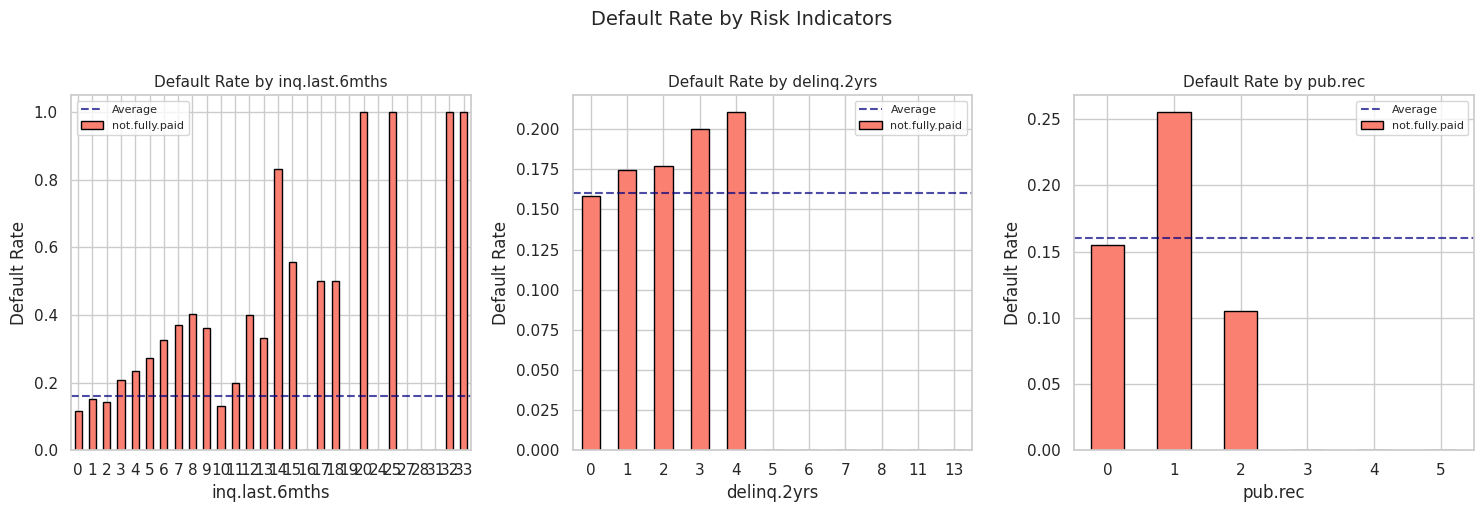

Observations:
- More credit inquiries in last 6 months → higher default risk
- Public records (bankruptcies) → strong default signal
- Delinquencies → moderate signal


In [22]:
# --- Risk Indicators: Delinquencies, Inquiries, Public Records ---
risk_cols = ['inq.last.6mths', 'delinq.2yrs', 'pub.rec']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(risk_cols):
    default_rate = df.groupby(col)['not.fully.paid'].mean()
    default_rate.plot(kind='bar', ax=axes[i], color='salmon', edgecolor='black')
    axes[i].set_title(f'Default Rate by {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Default Rate')
    axes[i].tick_params(rotation=0)
    axes[i].axhline(df['not.fully.paid'].mean(), color='navy',
                    linestyle='--', alpha=0.7, label='Average')
    axes[i].legend(fontsize=8)

plt.suptitle('Default Rate by Risk Indicators', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Observations:')
print('- More credit inquiries in last 6 months → higher default risk')
print('- Public records (bankruptcies) → strong default signal')
print('- Delinquencies → moderate signal')

## 5. Preprocessing

Preparing the data for modeling.

In [23]:
# --- Encode categorical variable 'purpose' ---
# We use get_dummies (one-hot encoding) to avoid ordinal assumption
df_model = pd.get_dummies(df, columns=['purpose'], drop_first=True)

print('Original shape:', df.shape)
print('After encoding:', df_model.shape)
print('\nNew columns from encoding:')
print([c for c in df_model.columns if 'purpose' in c])

Original shape: (9578, 14)
After encoding: (9578, 19)

New columns from encoding:
['purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_major_purchase', 'purpose_small_business']


In [24]:
# --- Train / Test Split ---
X = df_model.drop('not.fully.paid', axis=1)
y = df_model['not.fully.paid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f'Training set:  {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test set:      {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.1f}%)')
print()
print('Class balance in training set:')
print(y_train.value_counts(normalize=True).round(3))

Training set:  6,704 rows (70.0%)
Test set:      2,874 rows (30.0%)

Class balance in training set:
not.fully.paid
0   0.8400
1   0.1600
Name: proportion, dtype: float64


In [25]:
# --- Class Imbalance Note ---
# The dataset is imbalanced (~84% paid, ~16% default)
# This matters because a naive model that predicts "paid" always gets 84% accuracy
# but catches 0% of defaults — which is useless for a bank.
#
# Strategy used here: class_weight='balanced' in RandomForest
# This tells the model to weight the minority class higher during training.
#
# Other options (not applied here):
# - SMOTE (Synthetic Minority Oversampling)
# - Undersampling the majority class
# - Threshold tuning on predictions

print('Class distribution:')
print(f'  Class 0 (Paid):    {(y==0).sum():,} ({(y==0).mean():.1%})')
print(f'  Class 1 (Default): {(y==1).sum():,} ({(y==1).mean():.1%})')
print()
print('Imbalance ratio:', round((y==0).sum() / (y==1).sum(), 1), ':1')

Class distribution:
  Class 0 (Paid):    8,045 (84.0%)
  Class 1 (Default): 1,533 (16.0%)

Imbalance ratio: 5.2 :1


## 6. Predictive Model

We use **Random Forest** — an ensemble of decision trees that handles:
- Mixed data types (numeric + binary encoded)
- Non-linear relationships
- Feature importance ranking (useful for explaining the model)

In [26]:
# --- Train Random Forest ---
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',  # Handles class imbalance
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print('Model trained successfully')
print(f'Features used: {X_train.shape[1]}')

Model trained successfully
Features used: 18


In [27]:
# --- Evaluate on Test Set ---
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print('Classification Report:')
print('=' * 55)
print(classification_report(y_test, y_pred, target_names=['Paid', 'Default']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}')

Classification Report:
              precision    recall  f1-score   support

        Paid       0.86      0.88      0.87      2414
     Default       0.26      0.23      0.25       460

    accuracy                           0.77      2874
   macro avg       0.56      0.55      0.56      2874
weighted avg       0.76      0.77      0.77      2874

ROC-AUC Score: 0.6367


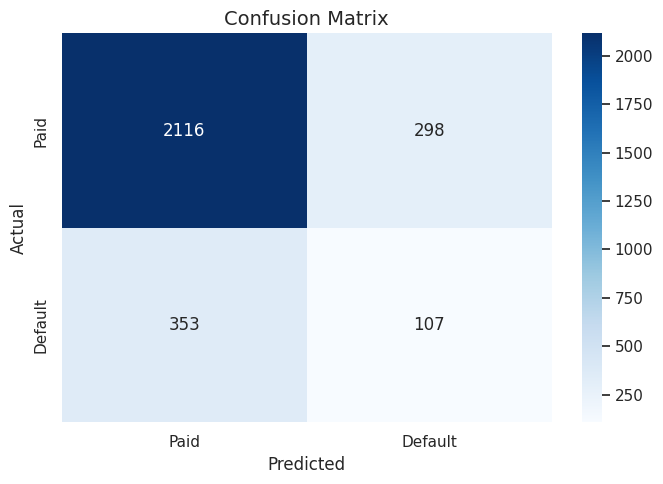

True Negatives  (Paid → Paid):       2,116
False Positives (Paid → Default):    298  ← loan denied incorrectly
False Negatives (Default → Paid):    353  ← missed default (costly!)
True Positives  (Default → Default): 107


In [28]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Paid', 'Default'],
            yticklabels=['Paid', 'Default'])
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (Paid → Paid):       {tn:,}')
print(f'False Positives (Paid → Default):    {fp:,}  ← loan denied incorrectly')
print(f'False Negatives (Default → Paid):    {fn:,}  ← missed default (costly!)')
print(f'True Positives  (Default → Default): {tp:,}')

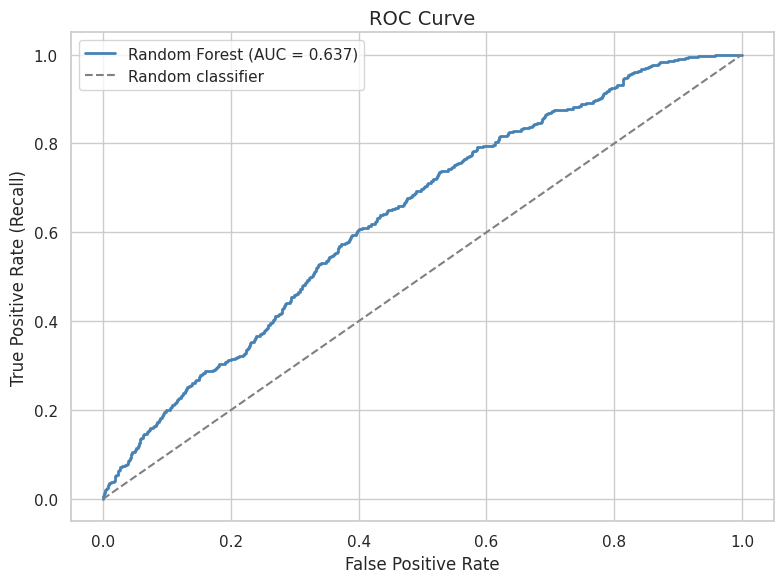

AUC of 0.5 = random guessing
AUC of 1.0 = perfect classifier
Our model: 0.637


In [29]:
# --- ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'Random Forest (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

print(f'AUC of 0.5 = random guessing')
print(f'AUC of 1.0 = perfect classifier')
print(f'Our model: {auc:.3f}')

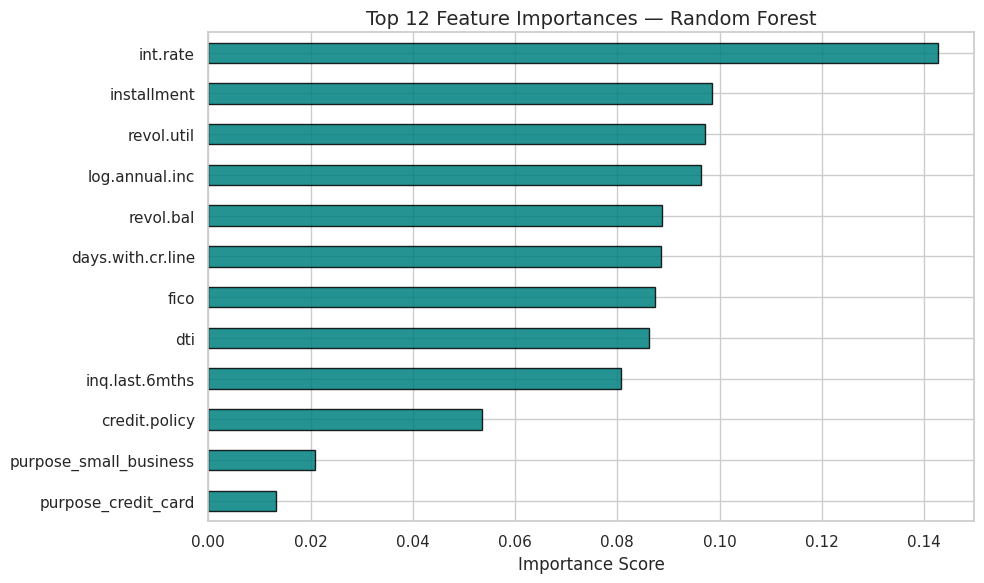

Top features driving default prediction:
  int.rate                       0.1426
  installment                    0.0985
  revol.util                     0.0972
  log.annual.inc                 0.0965
  revol.bal                      0.0887
  days.with.cr.line              0.0885
  fico                           0.0874
  dti                            0.0861
  inq.last.6mths                 0.0807
  credit.policy                  0.0535
  purpose_small_business         0.0208
  purpose_credit_card            0.0132


In [30]:
# --- Feature Importance ---
# Which features does the model rely on most?
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(12)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='teal', edgecolor='black', alpha=0.85)
plt.title('Top 12 Feature Importances — Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('Top features driving default prediction:')
for feat, imp in top_features.items():
    print(f'  {feat:<30} {imp:.4f}')

## 7. Conclusions & Key Insights

### Summary of findings

| Finding | Detail |
|---|---|
| **Default rate** | ~16% of loans defaulted — imbalanced dataset |
| **FICO score** | Strongest single predictor. Defaulters have lower FICO on average |
| **Interest rate** | Higher rate = higher default risk. Lender's risk pricing is directionally correct |
| **DTI** | Borrowers with higher debt-to-income ratios default more |
| **Purpose** | Small business loans have highest default rate; credit cards and major purchases are lower |
| **Credit policy** | Not meeting LendingClub's criteria is a strong default signal |
| **Public records** | Bankruptcies and derogatory records significantly increase default risk |

### Q&A — Presentation Prep

**Q1: Why are `fico` and `int.rate` correlated?**  
Because LendingClub sets interest rates based on credit risk. A borrower with a low FICO score is considered riskier, so the platform charges them a higher interest rate to compensate investors for the increased risk of default. It's not coincidence — it's intentional pricing.

**Q2: What is DTI and why does it matter?**  
DTI (Debt-to-Income ratio) = total monthly debt obligations / gross monthly income. A high DTI means the borrower is already spending a large portion of their income on debt payments. If they take on another loan, they have less financial buffer. Banks typically consider DTI > 43% as a high-risk threshold.

**Q3: How did you handle missing values?**  
This dataset had no missing values (confirmed in section 1). If there were any, the right strategy depends on the column: for numeric columns, median imputation is safer than mean (it's robust to outliers); for categoricals, a 'Unknown' category or mode imputation would be appropriate.

**Q4: Is the dataset balanced? What would you do if not?**  
No — 84% paid, 16% defaulted. This is a classic imbalanced classification problem. Our approach: `class_weight='balanced'` in RandomForest, which internally re-weights the loss function to penalize missing a default more than missing a paid loan. Alternatives: SMOTE oversampling, undersampling, or adjusting the classification threshold (e.g., flag as default if probability > 0.3 instead of 0.5).

**Q5: What model would you use in production?**  
Random Forest is a solid baseline, but for production I'd also evaluate:
- **XGBoost/LightGBM**: usually better accuracy on tabular financial data
- **Logistic Regression**: for interpretability and regulatory compliance (banks need to explain credit decisions by law in many jurisdictions)
- **Scorecard model**: traditional credit scoring, highly interpretable

The choice depends on whether the business needs interpretability (logistic regression) or maximum predictive power (gradient boosting).